In [32]:
import os
import pandas as pd
import torch
from tqdm import trange, tqdm
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

from utils.tools import calc_sig_strength_gpu, probabilistic_channel_model, createDirectory
from utils.config import Config, set_random_seed
from obstacles import create_obstacle_data, CubeObstacle, CylinderObstacle
from datasets import TrainDataset
from model import Net

In [33]:
%pwd

'/Users/ys.kang/Projects/DL-Based-UAV-Positioning-in-Blockage-Aware-Channel-Model/src/performance_evaluation'

In [34]:
bf_dir = os.path.join("..", "brute_force", "result")
f_ls = sorted([os.path.join(str(bf_dir), df) for df in os.listdir(bf_dir) if "mode_height" in df], key=str.lower)
df_ls = [pd.read_csv(f) for f in f_ls]
df_ls[2]

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z
0,65.835050,-48.765976,0.0,65.504745,53.760357,0.0,80.138920,19.723938,0.0,61.362625,65.013900,0.0,58.8,25.6,70
1,-9.900807,17.006355,0.0,-32.667140,32.489357,0.0,-89.948364,-23.443237,0.0,-97.831660,-99.264530,0.0,-70.6,0.0,70
2,64.189940,-35.482944,0.0,-53.927532,-71.294800,0.0,-75.638230,80.631920,0.0,-31.928122,47.596848,0.0,63.4,82.5,70
3,66.937480,59.828278,0.0,-59.673622,-89.957825,0.0,46.354916,-93.714630,0.0,11.758149,11.575461,0.0,44.9,-93.1,70
4,0.370089,-79.922430,0.0,-20.829224,83.274730,0.0,-22.561272,79.639800,0.0,62.053955,-75.342290,0.0,62.4,95.5,70
5,-18.273218,30.741210,0.0,-39.436306,-42.675540,0.0,56.907480,27.798399,0.0,59.795174,-84.311940,0.0,59.4,23.8,70
6,-91.091430,-37.701653,0.0,-41.712040,-88.678840,0.0,-98.465860,-75.451000,0.0,15.814892,18.671371,0.0,-74.2,-98.2,70
7,-21.397870,-38.694363,0.0,23.732906,17.682121,0.0,37.038400,81.945114,0.0,-39.569120,95.100870,0.0,-55.2,30.6,70
8,-34.239605,60.194782,0.0,25.115889,-76.825460,0.0,66.592860,-82.943680,0.0,-79.049310,53.878826,0.0,-56.8,-100.0,70
9,49.008840,85.065704,0.0,-49.997420,21.890747,0.0,-36.735910,-62.064995,0.0,-37.289524,18.452354,0.0,-28.8,12.6,70


In [35]:
cfg = Config(height=50, num_samples=10000)
obstacle_ls, obst_tensor = create_obstacle_data(cfg=cfg, return_type='both')

In [36]:
gus = torch.tensor(df_ls[2].iloc[:, :cfg.num_users * 3].values.reshape(-1, cfg.num_users, 3), dtype=torch.float32).to(cfg.device)
y = torch.tensor(df_ls[2].iloc[:, cfg.num_users * 3:].values, dtype=torch.float32).to(cfg.device)

In [37]:
y[0].unsqueeze(0).shape, gus[0].shape, obst_tensor.shape

(torch.Size([1, 3]), torch.Size([4, 3]), torch.Size([3566, 3]))

In [38]:
result = 0
for i in trange(len(gus)):
    result += calc_sig_strength_gpu(y[i].unsqueeze(0), gus[i], obst_tensor, cfg)

result /= len(gus)

100%|██████████| 10000/10000 [00:06<00:00, 1564.96it/s]


Probabilistic Channel Model U2_H70: 100%|██████████| 10000/10000 [07:54<00:00, 21.07it/s]
/var/folders/gm/x9jlk7p54xjc9qmd5h06cgd40000gn/T/ipykernel_88626/1473373953.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

Index(['gnd1_x', 'gnd1_y', 'gnd1_z', 'gnd2_x', 'gnd2_y', 'gnd2_z', 'bf_x',
       'bf_y', 'bf_z', 'cent_x', 'cent_y', 'cent_z', 'prob_x', 'prob_y',
       'prob_z', 'ours_x', 'ours_y', 'ours_z'],
      dtype='object')
      gnd1_x     gnd1_y  gnd1_z     gnd2_x     gnd2_y  gnd2_z       bf_x  \
0 -26.767437   6.268194     0.0  88.384040 -87.657820     0.0 -54.400002   
1  55.767940 -35.689270     0.0  59.672470 -78.144710     0.0  60.599998   
2  98.382770  37.109630     0.0 -87.915470 -87.780594     0.0  98.400002   
3 -45.098457 -69.351880     0.0  31.152685 -42.510350     0.0 -35.599998   
4 -25.741870 -45.459830     0.0  76.901040   1.328164     0.0  75.300003   

        bf_y  bf_z     cent_x     cent_y  cent_z     prob_x     prob_y  \
0 -81.400002  70.0  30.808302 -40.694813    70.0  -3.799995 -12.500000   
1 -57.000000  70.0  57.720207 -56.916988    70.0  57.699997 -56.899998   
2 -83.000000  70.0   5.233650 -25.335482    70.0  91.600006  32.600006   
3 -60.700001  70.0  -6.972886

Calc Result U2_H70: 100%|██████████| 10000/10000 [00:25<00:00, 389.90it/s]


U2_H70 BF: 13.0055, Centroid: 11.9890, Prob: 12.1488, Ours: 12.9265


Probabilistic Channel Model U3_H70: 100%|██████████| 10000/10000 [10:38<00:00, 15.66it/s]
/var/folders/gm/x9jlk7p54xjc9qmd5h06cgd40000gn/T/ipykernel_88626/1473373953.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

...

Probabilistic Channel Model U6_H70: 100%|██████████| 10000/10000 [13:36<00:00, 12.25it/s]
/var/folders/gm/x9jlk7p54xjc9qmd5h06cgd40000gn/T/ipykernel_88626/1473373953.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

Index(['gnd1_x', 'gnd1_y', 'gnd1_z', 'gnd2_x', 'gnd2_y', 'gnd2_z', 'gnd3_x',
       'gnd3_y', 'gnd3_z', 'gnd4_x', 'gnd4_y', 'gnd4_z', 'gnd5_x', 'gnd5_y',
       'gnd5_z', 'gnd6_x', 'gnd6_y', 'gnd6_z', 'bf_x', 'bf_y', 'bf_z',
       'cent_x', 'cent_y', 'cent_z', 'prob_x', 'prob_y', 'prob_z', 'ours_x',
       'ours_y', 'ours_z'],
      dtype='object')
      gnd1_x     gnd1_y  gnd1_z     gnd2_x     gnd2_y  gnd2_z     gnd3_x  \
0  33.381440 -94.929860     0.0 -31.561827  67.949844     0.0  61.204437   
1 -28.463003   2.524866     0.0  80.478230  89.652214     0.0 -44.827100   
2 -88.039970 -13.227165     0.0 -49.662334  62.459755     0.0  53.099747   
3  90.250110  99.304985     0.0 -82.832886 -75.337975     0.0 -85.579155   
4 -17.023457  34.695500     0.0   1.025011  83.458660     0.0  93.074470   

      gnd3_y  gnd3_z     gnd4_x     gnd4_y  gnd4_z     gnd5_x     gnd5_y  \
0 -54.869335     0.0 -53.848045  -8.991142     0.0 -52.203747  19.124258   
1  80.793015     0.0 -21.046524  13.987

Calc Result U6_H70: 100%|██████████| 10000/10000 [00:27<00:00, 365.79it/s]


U6_H70 BF: 12.2329, Centroid: 11.3156, Prob: 11.5566, Ours: 12.0613


<Figure size 1200x800 with 0 Axes>

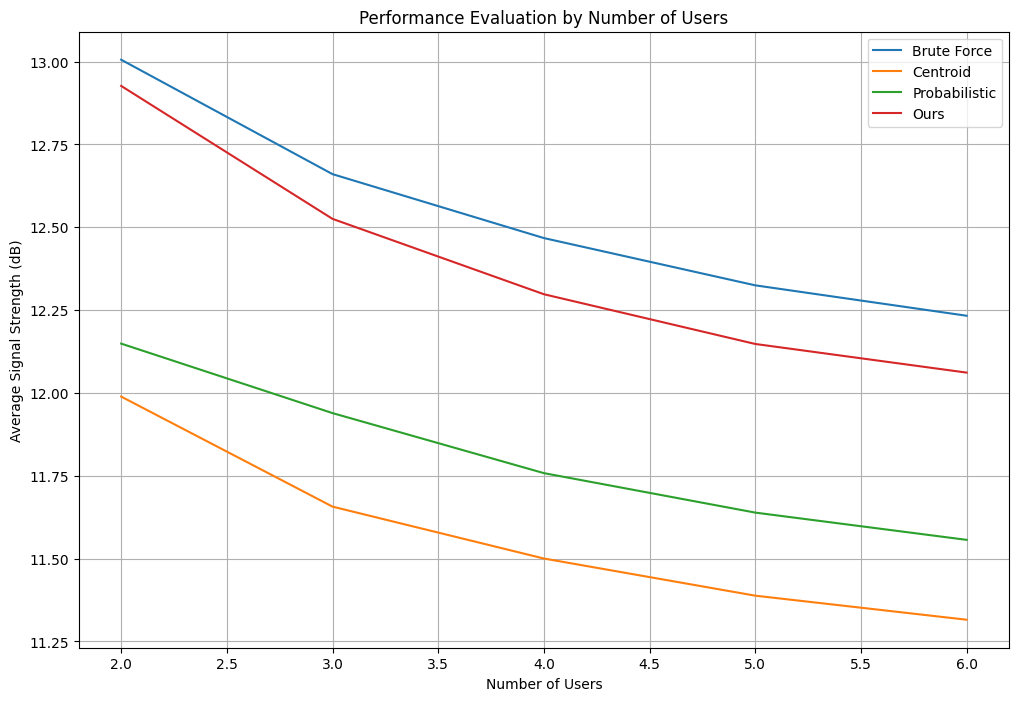

In [39]:
cfg = Config.performance_eval()
obstacle_ls, obst_tensor = create_obstacle_data(cfg=cfg, return_type='both')
bf_dir = os.path.join("..", "brute_force", "result")
result_dir = os.path.join(".", "result")
createDirectory(result_dir)

x_list, bf_list, cent_list, prob_list, ours_list = [], [], [], [], []

fig = plt.figure(figsize=(12, 8))

for test_cfg in Config.performance_eval_gen(mode='num_gu'):
    set_random_seed(test_cfg)
    obstacle_ls, obst_tensor = create_obstacle_data(cfg=test_cfg, return_type='both')
    df = pd.read_csv(os.path.join(bf_dir, f"mode_{test_cfg.mode}_U{test_cfg.num_users}_H{test_cfg.height}.csv"))

    # BF 데이터
    positions = torch.tensor(df.values,dtype=torch.float32, device=test_cfg.device)
    gus = positions[:, :test_cfg.num_users*3].reshape(-1, test_cfg.num_users, 3)
    bf  = positions[:, test_cfg.num_users*3:]

    # centroid 데이터
    centroid = torch.zeros_like(bf)
    for i in range(len(gus)):
        centroid[i] = gus[i].mean(dim=0)
        centroid[i][2] = test_cfg.height

    # probabilistic 채널 모델
    prob = torch.zeros_like(bf)
    for i in trange(len(gus), desc=f"Probabilistic Channel Model U{test_cfg.num_users}_H{test_cfg.height}"):
        prob_se = probabilistic_channel_model(gus[i], obstacle_ls, cfg=test_cfg)
        prob[i] = torch.tensor([(torch.argmax(prob_se) // prob_se.shape[1])*test_cfg.grid_step-test_cfg.area_size//2, (torch.argmax(prob_se) % prob_se.shape[1])*test_cfg.grid_step-test_cfg.area_size//2, test_cfg.height])

    # 비지도 학습
    ours = torch.zeros_like(bf)
    x = torch.tensor(df.drop(columns=df.columns[2::3]).iloc[:, :-2].values.reshape(-1, test_cfg.num_users* 2), dtype=torch.float32, device=test_cfg.device)
    x_scaled = test_cfg.scaler.transform(x.cpu())
    x_dataset = TrainDataset(x_scaled, dtype=torch.float32).to(test_cfg.device)
    val_dataloader = DataLoader(x_dataset, batch_size=1, shuffle=False)
    model_path = os.path.join("..", "train_model", "result", "models", test_cfg.mode, f"best_{test_cfg.mode}_{test_cfg.num_users if test_cfg.mode == 'num_gu' else test_cfg.height}.pt")

    model = Net(x_dataset.x.shape[1], 1024, 4, output_N=2).to(test_cfg.device)
    model.load_state_dict(torch.load(model_path, map_location=test_cfg.device))

    model.eval()
    with torch.no_grad():
        for i, x_batch in enumerate(tqdm(val_dataloader, desc=f"Ours U{test_cfg.num_users}_H{test_cfg.height}")):
            pred = model(x_batch)
            ours[i] = torch.hstack((pred * cfg.area_size - cfg.area_size / 2,
              torch.ones(pred.shape[0], 1, device=cfg.device) * cfg.height))

    # 결과 출력
    bf_result = 0
    centroid_result = 0
    prob_result = 0
    ours_result = 0

    base_df = df.copy(deep=True).iloc[:, :-3]
    # 텐서를 NumPy 배열로 변환
    bf_np   = bf.cpu().numpy()
    cent_np = centroid.cpu().numpy()
    prob_np = prob.cpu().numpy()
    ours_np = ours.cpu().numpy()

    # 컬럼명과 배열을 한 번에 매핑하여 DataFrame에 추가
    result_df = base_df.assign(
        bf_x   = bf_np[:, 0],
        bf_y   = bf_np[:, 1],
        bf_z   = bf_np[:, 2],

        cent_x = cent_np[:, 0],
        cent_y = cent_np[:, 1],
        cent_z = cent_np[:, 2],

        prob_x = prob_np[:, 0],
        prob_y = prob_np[:, 1],
        prob_z = prob_np[:, 2],

        ours_x = ours_np[:, 0],
        ours_y = ours_np[:, 1],
        ours_z = ours_np[:, 2],
    )

    # 확인
    print(result_df.columns)
    print(result_df.head())

    for i in trange(len(gus), desc=f"Calc Result U{test_cfg.num_users}_H{test_cfg.height}"):
        bf_result += calc_sig_strength_gpu(bf[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)
        centroid_result += calc_sig_strength_gpu(centroid[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)
        prob_result += calc_sig_strength_gpu(prob[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)
        ours_result += calc_sig_strength_gpu(ours[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)

    bf_result /= len(gus)
    centroid_result /= len(gus)
    prob_result /= len(gus)
    ours_result /= len(gus)
    x_list.append(test_cfg.num_users)
    bf_list.append(float(bf_result))
    cent_list.append(float(centroid_result))
    prob_list.append(float(prob_result))
    ours_list.append(float(ours_result))

    print(f"U{test_cfg.num_users}_H{test_cfg.height} BF: {float(bf_result):.4f}, Centroid: {float(centroid_result):.4f}, Prob: {float(prob_result):.4f}, Ours: {float(ours_result):.4f}")
    result_df.to_csv(os.path.join(result_dir, f"eval_mode_{test_cfg.mode}_U{test_cfg.num_users}_H{test_cfg.height}.csv"), index=False)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_list, bf_list,  label="Brute Force")
ax.plot(x_list, cent_list, label="Centroid")
ax.plot(x_list, prob_list, label="Probabilistic")
ax.plot(x_list, ours_list, label="Ours")
ax.set(xlabel="Number of Users", ylabel="Average Signal Strength (dB)",
       title="Performance Evaluation by Number of Users")
ax.grid()
ax.legend()
plt.show()

In [40]:
x_list = [2, 3, 4, 5, 6]

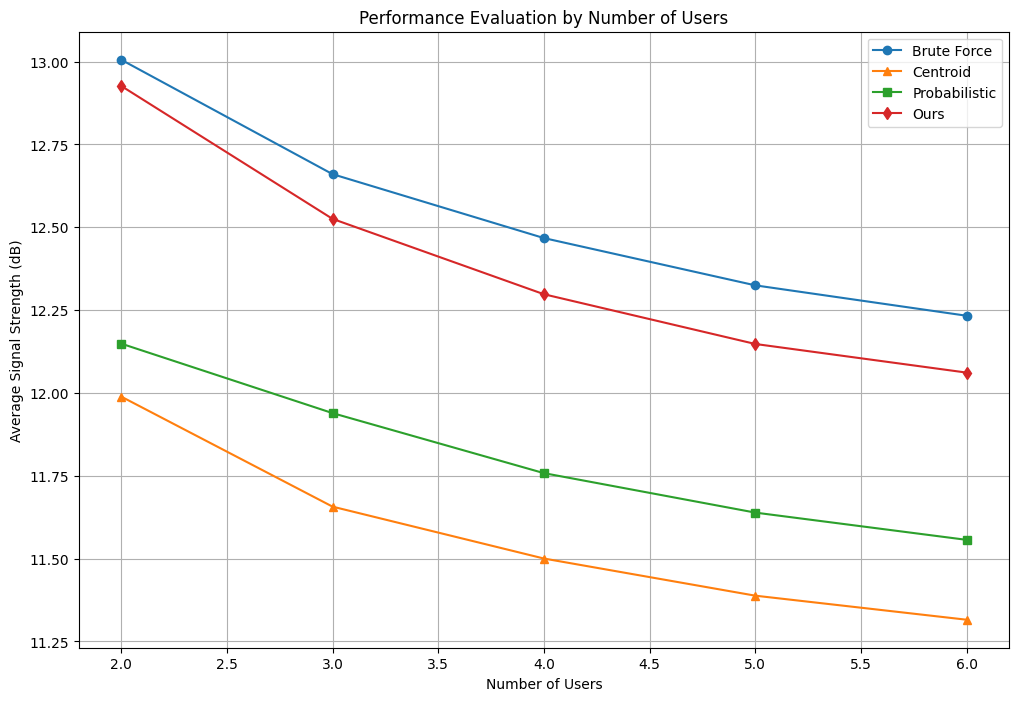

In [41]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_list, bf_list,  marker='o', label="Brute Force")
ax.plot(x_list, cent_list, marker='^', label="Centroid")
ax.plot(x_list, prob_list, marker='s', label="Probabilistic")
ax.plot(x_list, ours_list, marker='d', label="Ours")
ax.set(xlabel="Number of Users", ylabel="Average Signal Strength (dB)",
       title="Performance Evaluation by Number of Users")
ax.grid()
ax.legend()
plt.show()

In [42]:
print(torch.tensor(ours_list)/torch.tensor(bf_list))
print(torch.tensor(prob_list)/torch.tensor(bf_list))
print(torch.tensor(cent_list)/torch.tensor(bf_list))

tensor([0.9939, 0.9893, 0.9864, 0.9856, 0.9860])
tensor([0.9341, 0.9430, 0.9431, 0.9444, 0.9447])
tensor([0.9218, 0.9207, 0.9224, 0.9240, 0.9250])


In [43]:
print(bf_list)
print(ours_list)
print(prob_list)
print(cent_list)
print(torch.tensor(bf_list)-torch.tensor(ours_list))
print(torch.tensor(ours_list)-torch.tensor(prob_list))

[13.005526542663574, 12.660221099853516, 12.467310905456543, 12.324670791625977, 12.232935905456543]
[12.926477432250977, 12.525257110595703, 12.297846794128418, 12.147754669189453, 12.061347007751465]
[12.148813247680664, 11.93912124633789, 11.75796890258789, 11.63886547088623, 11.556623458862305]
[11.988982200622559, 11.656867027282715, 11.500287055969238, 11.388179779052734, 11.315619468688965]
tensor([0.0790, 0.1350, 0.1695, 0.1769, 0.1716])
tensor([0.7777, 0.5861, 0.5399, 0.5089, 0.5047])


Probabilistic Channel Model U4_H50: 100%|██████████| 10000/10000 [12:22<00:00, 13.47it/s]
/var/folders/gm/x9jlk7p54xjc9qmd5h06cgd40000gn/T/ipykernel_88626/2612013888.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

Index(['gnd1_x', 'gnd1_y', 'gnd1_z', 'gnd2_x', 'gnd2_y', 'gnd2_z', 'gnd3_x',
       'gnd3_y', 'gnd3_z', 'gnd4_x', 'gnd4_y', 'gnd4_z', 'bf_x', 'bf_y',
       'bf_z', 'cent_x', 'cent_y', 'cent_z', 'prob_x', 'prob_y', 'prob_z',
       'ours_x', 'ours_y', 'ours_z'],
      dtype='object')
      gnd1_x     gnd1_y  gnd1_z     gnd2_x     gnd2_y  gnd2_z     gnd3_x  \
0  65.835050 -48.765976     0.0  65.504745  53.760357     0.0  80.138920   
1  -9.900807  17.006355     0.0 -32.667140  32.489357     0.0 -89.948364   
2  64.189940 -35.482944     0.0 -53.927532 -71.294800     0.0 -75.638230   
3  66.937480  59.828278     0.0 -59.673622 -89.957825     0.0  46.354916   
4   0.370089 -79.922430     0.0 -20.829224  83.274730     0.0 -22.561272   

      gnd3_y  gnd3_z     gnd4_x     gnd4_y  gnd4_z       bf_x       bf_y  \
0  19.723938     0.0  61.362625  65.013900     0.0  60.900002  26.900000   
1 -23.443237     0.0 -97.831660 -99.264530     0.0 -89.800003 -21.299999   
2  80.631920     0.0 -31.92812

Calc Result U4_H50: 100%|██████████| 10000/10000 [00:26<00:00, 376.52it/s]


U4_H50 BF: 12.6025, Centroid: 11.7002, Prob: 12.0154, Ours: 12.4543


Probabilistic Channel Model U4_H60: 100%|██████████| 10000/10000 [12:23<00:00, 13.45it/s]
/var/folders/gm/x9jlk7p54xjc9qmd5h06cgd40000gn/T/ipykernel_88626/2612013888.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

...

Probabilistic Channel Model U4_H90: 100%|██████████| 10000/10000 [12:22<00:00, 13.47it/s]
/var/folders/gm/x9jlk7p54xjc9qmd5h06cgd40000gn/T/ipykernel_88626/2612013888.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

Index(['gnd1_x', 'gnd1_y', 'gnd1_z', 'gnd2_x', 'gnd2_y', 'gnd2_z', 'gnd3_x',
       'gnd3_y', 'gnd3_z', 'gnd4_x', 'gnd4_y', 'gnd4_z', 'bf_x', 'bf_y',
       'bf_z', 'cent_x', 'cent_y', 'cent_z', 'prob_x', 'prob_y', 'prob_z',
       'ours_x', 'ours_y', 'ours_z'],
      dtype='object')
      gnd1_x     gnd1_y  gnd1_z     gnd2_x     gnd2_y  gnd2_z     gnd3_x  \
0  65.835050 -48.765976     0.0  65.504745  53.760357     0.0  80.138920   
1  -9.900807  17.006355     0.0 -32.667140  32.489357     0.0 -89.948364   
2  64.189940 -35.482944     0.0 -53.927532 -71.294800     0.0 -75.638230   
3  66.937480  59.828278     0.0 -59.673622 -89.957825     0.0  46.354916   
4   0.370089 -79.922430     0.0 -20.829224  83.274730     0.0 -22.561272   

      gnd3_y  gnd3_z     gnd4_x     gnd4_y  gnd4_z       bf_x       bf_y  \
0  19.723938     0.0  61.362625  65.013900     0.0  56.299999  24.299999   
1 -23.443237     0.0 -97.831660 -99.264530     0.0 -76.900002  -7.500000   
2  80.631920     0.0 -31.92812

Calc Result U4_H90: 100%|██████████| 10000/10000 [00:26<00:00, 375.57it/s]

U4_H90 BF: 12.3407, Centroid: 11.4404, Prob: 11.5946, Ours: 12.1512


<Figure size 1200x800 with 0 Axes>

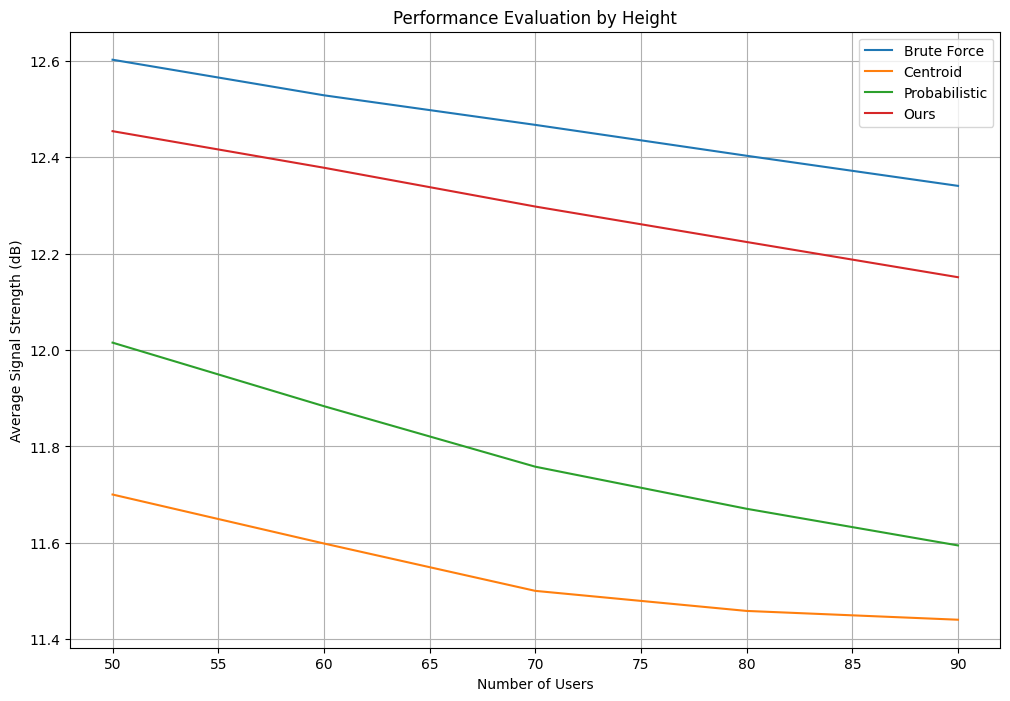

In [44]:
cfg = Config.performance_eval()
obstacle_ls, obst_tensor = create_obstacle_data(cfg=cfg, return_type='both')
bf_dir = os.path.join("..", "brute_force", "result")
result_dir = os.path.join(".", "result")
createDirectory(result_dir)

x_list, bf_list, cent_list, prob_list, ours_list = [], [], [], [], []

fig = plt.figure(figsize=(12, 8))

for test_cfg in Config.performance_eval_gen(mode='height'):
    set_random_seed(test_cfg)
    obstacle_ls, obst_tensor = create_obstacle_data(cfg=test_cfg, return_type='both')
    df = pd.read_csv(os.path.join(bf_dir, f"mode_{test_cfg.mode}_U{test_cfg.num_users}_H{test_cfg.height}.csv"))

    # BF 데이터
    positions = torch.tensor(df.values,dtype=torch.float32, device=test_cfg.device)
    gus = positions[:, :test_cfg.num_users*3].reshape(-1, test_cfg.num_users, 3)
    bf  = positions[:, test_cfg.num_users*3:]

    # centroid 데이터
    centroid = torch.zeros_like(bf)
    for i in range(len(gus)):
        centroid[i] = gus[i].mean(dim=0)
        centroid[i][2] = test_cfg.height

    # probabilistic 채널 모델
    prob = torch.zeros_like(bf)
    for i in trange(len(gus), desc=f"Probabilistic Channel Model U{test_cfg.num_users}_H{test_cfg.height}"):
        prob_se = probabilistic_channel_model(gus[i], obstacle_ls, cfg=test_cfg)
        prob[i] = torch.tensor([(torch.argmax(prob_se) // prob_se.shape[1])*test_cfg.grid_step-test_cfg.area_size//2, (torch.argmax(prob_se) % prob_se.shape[1])*test_cfg.grid_step-test_cfg.area_size//2, test_cfg.height])

    # 비지도 학습
    ours = torch.zeros_like(bf)
    x = torch.tensor(df.drop(columns=df.columns[2::3]).iloc[:, :-2].values.reshape(-1, test_cfg.num_users* 2), dtype=torch.float32, device=test_cfg.device)
    x_scaled = test_cfg.scaler.transform(x.cpu())
    x_dataset = TrainDataset(x_scaled, dtype=torch.float32).to(test_cfg.device)
    val_dataloader = DataLoader(x_dataset, batch_size=1, shuffle=False)
    model_path = os.path.join("..", "train_model", "result", "models", test_cfg.mode, f"best_{test_cfg.mode}_{test_cfg.num_users if test_cfg.mode == 'num_gu' else test_cfg.height}.pt")

    model = Net(x_dataset.x.shape[1], 1024, 4, output_N=2).to(test_cfg.device)
    model.load_state_dict(torch.load(model_path, map_location=test_cfg.device))

    model.eval()
    with torch.no_grad():
        for i, x_batch in enumerate(tqdm(val_dataloader, desc=f"Ours U{test_cfg.num_users}_H{test_cfg.height}")):
            pred = model(x_batch)
            ours[i] = torch.hstack((pred * test_cfg.area_size - test_cfg.area_size / 2,
              torch.ones(pred.shape[0], 1, device=test_cfg.device) * test_cfg.height))

    # 결과 출력
    bf_result = 0
    centroid_result = 0
    prob_result = 0
    ours_result = 0

    base_df = df.copy(deep=True).iloc[:, :-3]
    # 텐서를 NumPy 배열로 변환
    bf_np   = bf.cpu().numpy()
    cent_np = centroid.cpu().numpy()
    prob_np = prob.cpu().numpy()
    ours_np = ours.cpu().numpy()

    # 컬럼명과 배열을 한 번에 매핑하여 DataFrame에 추가
    result_df = base_df.assign(
        bf_x   = bf_np[:, 0],
        bf_y   = bf_np[:, 1],
        bf_z   = bf_np[:, 2],

        cent_x = cent_np[:, 0],
        cent_y = cent_np[:, 1],
        cent_z = cent_np[:, 2],

        prob_x = prob_np[:, 0],
        prob_y = prob_np[:, 1],
        prob_z = prob_np[:, 2],

        ours_x = ours_np[:, 0],
        ours_y = ours_np[:, 1],
        ours_z = ours_np[:, 2],
    )

    # 확인
    print(result_df.columns)
    print(result_df.head())

    for i in trange(len(gus), desc=f"Calc Result U{test_cfg.num_users}_H{test_cfg.height}"):
        bf_result += calc_sig_strength_gpu(bf[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)
        centroid_result += calc_sig_strength_gpu(centroid[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)
        prob_result += calc_sig_strength_gpu(prob[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)
        ours_result += calc_sig_strength_gpu(ours[i].unsqueeze(0), gus[i], obst_tensor, test_cfg)

    bf_result /= len(gus)
    centroid_result /= len(gus)
    prob_result /= len(gus)
    ours_result /= len(gus)
    x_list.append(test_cfg.height)
    bf_list.append(float(bf_result))
    cent_list.append(float(centroid_result))
    prob_list.append(float(prob_result))
    ours_list.append(float(ours_result))

    print(f"U{test_cfg.num_users}_H{test_cfg.height} BF: {float(bf_result):.4f}, Centroid: {float(centroid_result):.4f}, Prob: {float(prob_result):.4f}, Ours: {float(ours_result):.4f}")
    result_df.to_csv(os.path.join(result_dir, f"eval_mode_{test_cfg.mode}_U{test_cfg.num_users}_H{test_cfg.height}.csv"), index=False)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_list, bf_list,  label="Brute Force")
ax.plot(x_list, cent_list, label="Centroid")
ax.plot(x_list, prob_list, label="Probabilistic")
ax.plot(x_list, ours_list, label="Ours")
ax.set(xlabel="Number of Users", ylabel="Average Signal Strength (dB)",
       title="Performance Evaluation by Height")
ax.grid()
ax.legend()
plt.show()

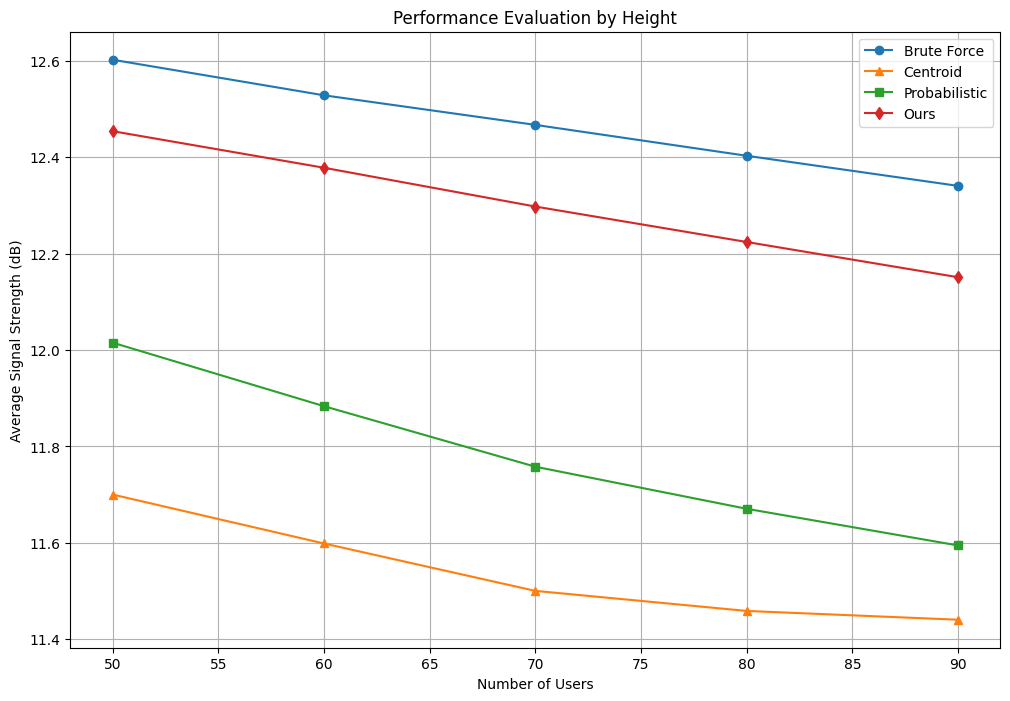

In [45]:
x_list = [50, 60, 70, 80, 90]

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_list, bf_list,  marker='o', label="Brute Force")
ax.plot(x_list, cent_list, marker='^', label="Centroid")
ax.plot(x_list, prob_list, marker='s', label="Probabilistic")
ax.plot(x_list, ours_list, marker='d', label="Ours")
ax.set(xlabel="Number of Users", ylabel="Average Signal Strength (dB)",
       title="Performance Evaluation by Height")
ax.grid()
ax.legend()
plt.show()